# Bike Sharing Project Pipeline with Hourly Data

This notebook builds a first full project pipeline for the hourly bike sharing dataset.

The notebook now includes:
- preprocessing and exploratory analysis for the hourly series
- a more detailed dependence analysis
- a classical `ARIMA` benchmark
- a `Lagged Regression` model
- an `LSTM` window comparison
- a matching `RNN` benchmark
- an optional `ARIMAX` extension module

The overall goal is to make it easy to judge which direction is most promising before turning this into a more polished final project notebook.

In [1]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'
os.environ['TORCHDYNAMO_DISABLE'] = '1'

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

def find_project_root(start=Path.cwd()):
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'data' / 'hour.csv').exists():
            return path
    raise FileNotFoundError('Could not find data/hour.csv from the current working directory.')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
DATA_PATH = DATA_DIR / 'hour.csv'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Experiment configuration for the first-pass pipeline
SEQ_EPOCHS = 20
SEQ_HIDDEN_SIZE = 32
LSTM_WINDOWS = [24, 72, 168]
RUN_ARIMAX = True
ARIMAX_ORDER = (1, 0, 0)
ARIMAX_MAXITER = 100

## 1. Load and preprocess the hourly dataset

The raw data store the date and hour separately, so we first combine them into a timestamp. Then we rebuild a complete hourly grid because the dataset contains missing timestamps.

For this first project pipeline, the missing-hour treatment stays simple:
- continuous variables are interpolated over time
- `weathersit` is forward-filled then back-filled
- calendar variables are rebuilt from the timestamp
- `is_imputed` marks the rows that were filled in

This keeps the notebook lightweight while still giving us a usable hourly modeling dataset.

In [2]:
raw_df = pd.read_csv(DATA_PATH, parse_dates=['dteday'])
raw_df['timestamp'] = raw_df['dteday'] + pd.to_timedelta(raw_df['hr'], unit='h')
raw_df = raw_df.sort_values('timestamp').reset_index(drop=True)

full_index = pd.date_range(raw_df['timestamp'].min(), raw_df['timestamp'].max(), freq='h')

overview = pd.Series({
    'rows': len(raw_df),
    'start_timestamp': raw_df['timestamp'].min(),
    'end_timestamp': raw_df['timestamp'].max(),
    'duplicate_timestamps': int(raw_df['timestamp'].duplicated().sum()),
    'expected_hours': len(full_index),
    'observed_hours': len(raw_df),
    'missing_hours': len(full_index) - len(raw_df),
})

overview

rows                                  17379
start_timestamp         2011-01-01 00:00:00
end_timestamp           2012-12-31 23:00:00
duplicate_timestamps                      0
expected_hours                        17544
observed_hours                        17379
missing_hours                           165
dtype: object

In [3]:
hourly_df = raw_df.set_index('timestamp').reindex(full_index)
hourly_df.index.name = 'timestamp'

hourly_df['is_imputed'] = hourly_df['cnt'].isna().astype(int)
hourly_df['date'] = hourly_df.index.normalize()

holiday_map = raw_df.groupby(raw_df['timestamp'].dt.normalize())['holiday'].first()
hourly_df['holiday'] = hourly_df['date'].map(holiday_map).fillna(0).astype(int)

hourly_df['yr'] = hourly_df.index.year - 2011
hourly_df['mnth'] = hourly_df.index.month
hourly_df['hr'] = hourly_df.index.hour
hourly_df['weekday'] = (hourly_df.index.dayofweek + 1) % 7
hourly_df['workingday'] = ((hourly_df['weekday'].isin([1, 2, 3, 4, 5])) & (hourly_df['holiday'] == 0)).astype(int)

month_to_season = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
}
hourly_df['season'] = hourly_df['mnth'].map(month_to_season)

for col in ['cnt', 'temp', 'atemp', 'hum', 'windspeed']:
    hourly_df[col] = hourly_df[col].interpolate(method='time')

hourly_df['cnt'] = hourly_df['cnt'].clip(lower=0)
hourly_df['weathersit'] = hourly_df['weathersit'].ffill().bfill()

model_df = hourly_df[[
    'cnt', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
    'weathersit', 'temp', 'hum', 'windspeed', 'is_imputed'
]].copy()

model_df.head()

,cnt,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,is_imputed
timestamp,,,,,,,,,,,,,
2011-01-01 00:00:00,16.0,1,0,1,0,0,6,0,1.0,0.24,0.81,0.0,0
2011-01-01 01:00:00,40.0,1,0,1,1,0,6,0,1.0,0.22,0.80,0.0,0
2011-01-01 02:00:00,32.0,1,0,1,2,0,6,0,1.0,0.22,0.80,0.0,0
2011-01-01 03:00:00,13.0,1,0,1,3,0,6,0,1.0,0.24,0.75,0.0,0
2011-01-01 04:00:00,1.0,1,0,1,4,0,6,0,1.0,0.24,0.75,0.0,0


A few modeling notes:
- `casual` and `registered` are excluded because they add up exactly to `cnt`, which would cause leakage.
- `temp` is kept while `atemp` is dropped for simplicity because the two variables are very similar.
- This notebook treats `Lagged Regression`, `LSTM`, and `RNN` as conditional forecasting models that may use external information available at prediction time.

## 2. First look at temporal structure

For the proposal, it is more useful to build one figure that directly supports the time-series motivation.

This figure focuses on four patterns:
- a representative short time window of the hourly series
- the weekly hourly pattern across days of the week
- differences between working and non-working days
- autocorrelation at short, daily, and weekly lags


In [ ]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from statsmodels.tsa.stattools import acf

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.frameon': False,
})

primary = '#234E70'
secondary = '#4F6D7A'
accent = '#D97B66'
weekend = '#F4A261'
neutral = '#9AA5B1'

sample_start = pd.Timestamp('2012-08-06 00:00')
sample_end = pd.Timestamp('2012-08-19 23:00')
segment = model_df.loc[sample_start:sample_end].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.flatten()

# A. Representative short interval
for day, day_df in segment.groupby(segment.index.normalize()):
    if int(day_df['workingday'].iloc[0]) == 0:
        ax1.axvspan(day, day + pd.Timedelta(days=1), color=weekend, alpha=0.14, lw=0)

ax1.plot(segment.index, segment['cnt'], color=primary, lw=1.4)
ax1.set_title('A. Representative Two-Week Segment', loc='left')
ax1.set_ylabel('Hourly rentals')
ax1.set_xlabel('Date')
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.legend(
    handles=[
        Line2D([0], [0], color=primary, lw=1.8, label='Hourly demand'),
        Line2D([0], [0], color=weekend, lw=6, alpha=0.35, label='Non-working day'),
    ],
    loc='upper left',
    ncol=2,
)

# B. Weekly hourly pattern
heat_df = model_df.copy()
heat_df['day_name'] = pd.Categorical(
    heat_df.index.day_name().str[:3],
    categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    ordered=True,
)
heatmap_data = heat_df.pivot_table(
    index='day_name', columns='hr', values='cnt', aggfunc='median'
).loc[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']]

im = ax2.imshow(heatmap_data.values, aspect='auto', cmap='Blues', origin='upper')
ax2.set_title('B. Weekly Hourly Pattern', loc='left')
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Day of week')
ax2.set_xticks(np.arange(0, 24, 3))
ax2.set_yticks(np.arange(len(heatmap_data.index)))
ax2.set_yticklabels(heatmap_data.index)
cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Median rentals')

# C. Working vs non-working day profiles
profile = (
    model_df.assign(day_type=np.where(model_df['workingday'] == 1, 'Working day', 'Non-working day'))
    .groupby(['day_type', 'hr'])['cnt']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

for label, color in [('Working day', primary), ('Non-working day', accent)]:
    sub = profile[profile['day_type'] == label].sort_values('hr')
    ax3.plot(sub['hr'], sub['median'], color=color, lw=2.0, label=label)
    ax3.fill_between(
        sub['hr'].to_numpy(),
        sub['q25'].to_numpy(),
        sub['q75'].to_numpy(),
        color=color,
        alpha=0.16,
    )

ax3.set_title('C. Hourly Profiles by Working Status', loc='left')
ax3.set_xlabel('Hour of day')
ax3.set_ylabel('Rentals')
ax3.set_xticks(np.arange(0, 24, 3))
ax3.legend(loc='upper left')

# D. Autocorrelation with highlighted lags
max_lag = 192
acf_vals = acf(model_df['cnt'].to_numpy(), nlags=max_lag, fft=True)
lags = np.arange(1, max_lag + 1)
conf = 1.96 / np.sqrt(model_df['cnt'].shape[0])

ax4.axhspan(-conf, conf, color=neutral, alpha=0.18)
ax4.vlines(lags, 0, acf_vals[1:], color=secondary, lw=1.0, alpha=0.85)
ax4.axhline(0, color='black', lw=0.8)

key_lags = np.array([1, 2, 3, 24, 168])
ax4.vlines(key_lags, 0, acf_vals[key_lags], color=accent, lw=2.2)
ax4.scatter(key_lags, acf_vals[key_lags], color=accent, s=24, zorder=3)
for lag in key_lags:
    ax4.text(lag, acf_vals[lag] + 0.035, str(lag), ha='center', va='bottom', fontsize=8, color=accent)

ax4.set_title('D. Autocorrelation of Hourly Demand', loc='left')
ax4.set_xlabel('Lag (hours)')
ax4.set_ylabel('ACF')
ax4.set_xlim(0, max_lag + 2)
ax4.set_ylim(-0.12, 1.02)
ax4.set_xticks([0, 24, 48, 72, 96, 120, 144, 168, 192])

for ax in axes.flat:
    ax.grid(True, axis='y', alpha=0.25)

output_dir = FIGURES_DIR
output_dir.mkdir(exist_ok=True)
output_path = output_dir / 'hourly_demand_structure.png'
fig.savefig(output_path, bbox_inches='tight')

plt.show()
print(f'Saved figure to: {output_path}')
print({lag: round(float(acf_vals[lag]), 3) for lag in key_lags})


In [5]:
summary_table = pd.DataFrame({
    'mean_cnt_by_workingday': model_df.groupby('workingday')['cnt'].mean(),
    'median_cnt_by_workingday': model_df.groupby('workingday')['cnt'].median(),
})

corr_view = model_df[['cnt', 'temp', 'hum', 'windspeed']].corr()['cnt'].sort_values(ascending=False)

summary_table, corr_view

(            mean_cnt_by_workingday  median_cnt_by_workingday
 workingday                                                  
 0                       180.469517                     119.0
 1                       191.313125                     149.0,
 cnt          1.000000
 temp         0.409319
 windspeed    0.086004
 hum         -0.325274
 Name: cnt, dtype: float64)

## 3. Dependence analysis

This is the key diagnostic section for the project design. We study dependence in:
- the raw hourly series
- the first-differenced series
- the 24-hour differenced series

The main question is whether a plain non-seasonal `ARIMA` is enough on the raw hourly data. The dependence plots show why the answer is mostly no: the daily cycle is too strong. That motivates fitting the classical `ARIMA` benchmark on the 24-hour differenced series instead.

In [6]:
selected_lags = [1, 2, 3, 24, 25, 48, 168]

def lag_autocorr(series, lags):
    return pd.Series({f'lag_{lag}': series.autocorr(lag=lag) for lag in lags})

diff_1 = model_df['cnt'].diff().dropna()
diff_24 = model_df['cnt'].diff(24).dropna()

acf_summary = pd.DataFrame({
    'raw_cnt': lag_autocorr(model_df['cnt'], selected_lags),
    'diff_1': lag_autocorr(diff_1, selected_lags),
    'diff_24': lag_autocorr(diff_24, selected_lags),
})

acf_summary

,raw_cnt,diff_1,diff_24
lag_1,0.845102,0.299289,0.746392
lag_2,0.597473,-0.192036,0.412164
lag_3,0.409326,-0.184229,0.174998
lag_24,0.819798,0.705126,-0.131287
lag_25,0.711969,0.255590,-0.091517
lag_48,0.686727,0.499782,-0.243187
lag_168,0.872386,0.832243,0.447096


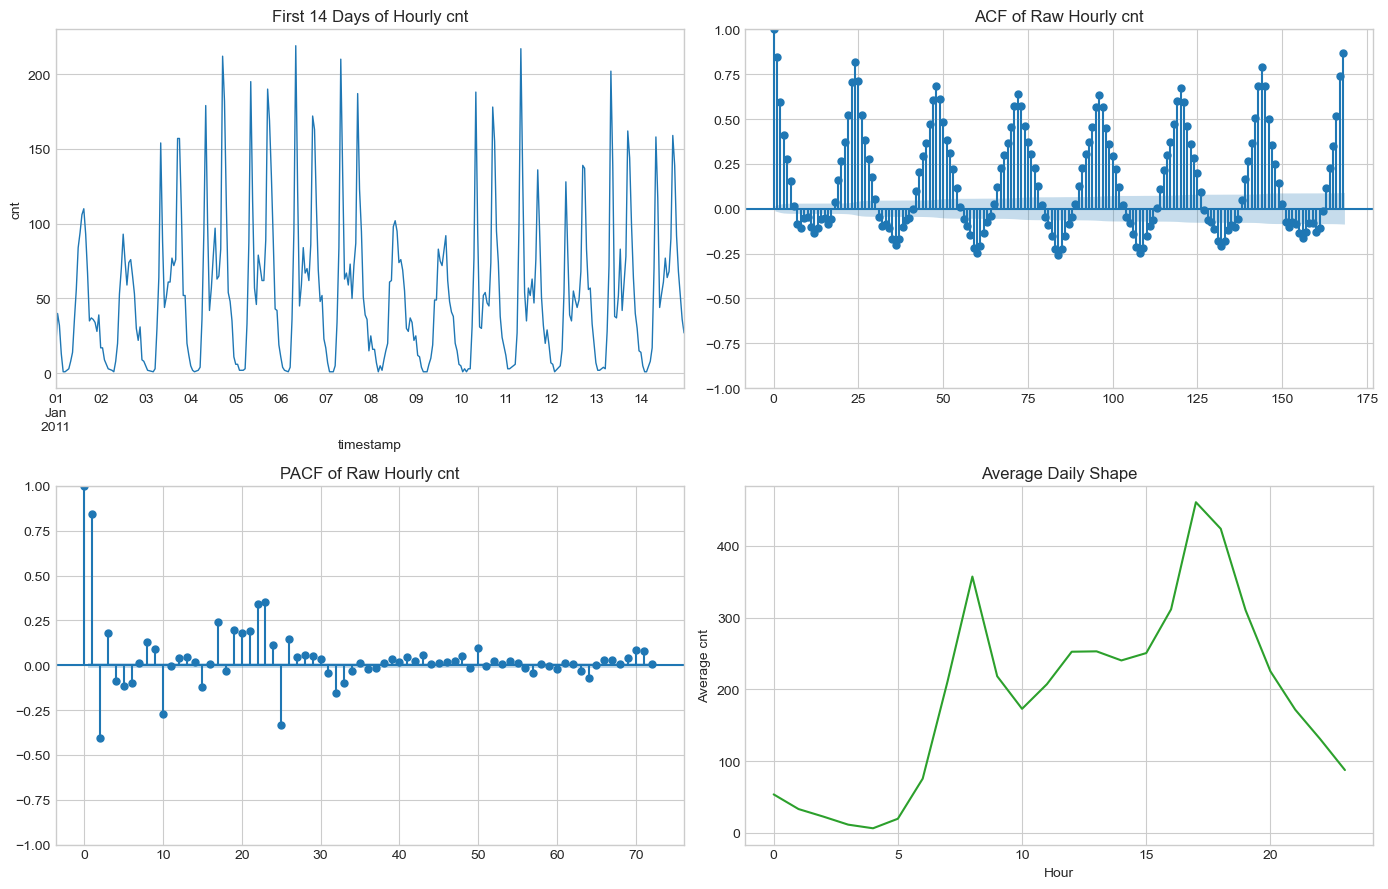

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

model_df['cnt'].iloc[:24 * 14].plot(ax=axes[0, 0], color='tab:blue', lw=1)
axes[0, 0].set_title('First 14 Days of Hourly cnt')
axes[0, 0].set_ylabel('cnt')

plot_acf(model_df['cnt'], lags=168, ax=axes[0, 1])
axes[0, 1].set_title('ACF of Raw Hourly cnt')

plot_pacf(model_df['cnt'], lags=72, ax=axes[1, 0], method='ywm')
axes[1, 0].set_title('PACF of Raw Hourly cnt')

axes[1, 1].plot(model_df.groupby('hr')['cnt'].mean(), color='tab:green')
axes[1, 1].set_title('Average Daily Shape')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Average cnt')

plt.tight_layout()
plt.show()

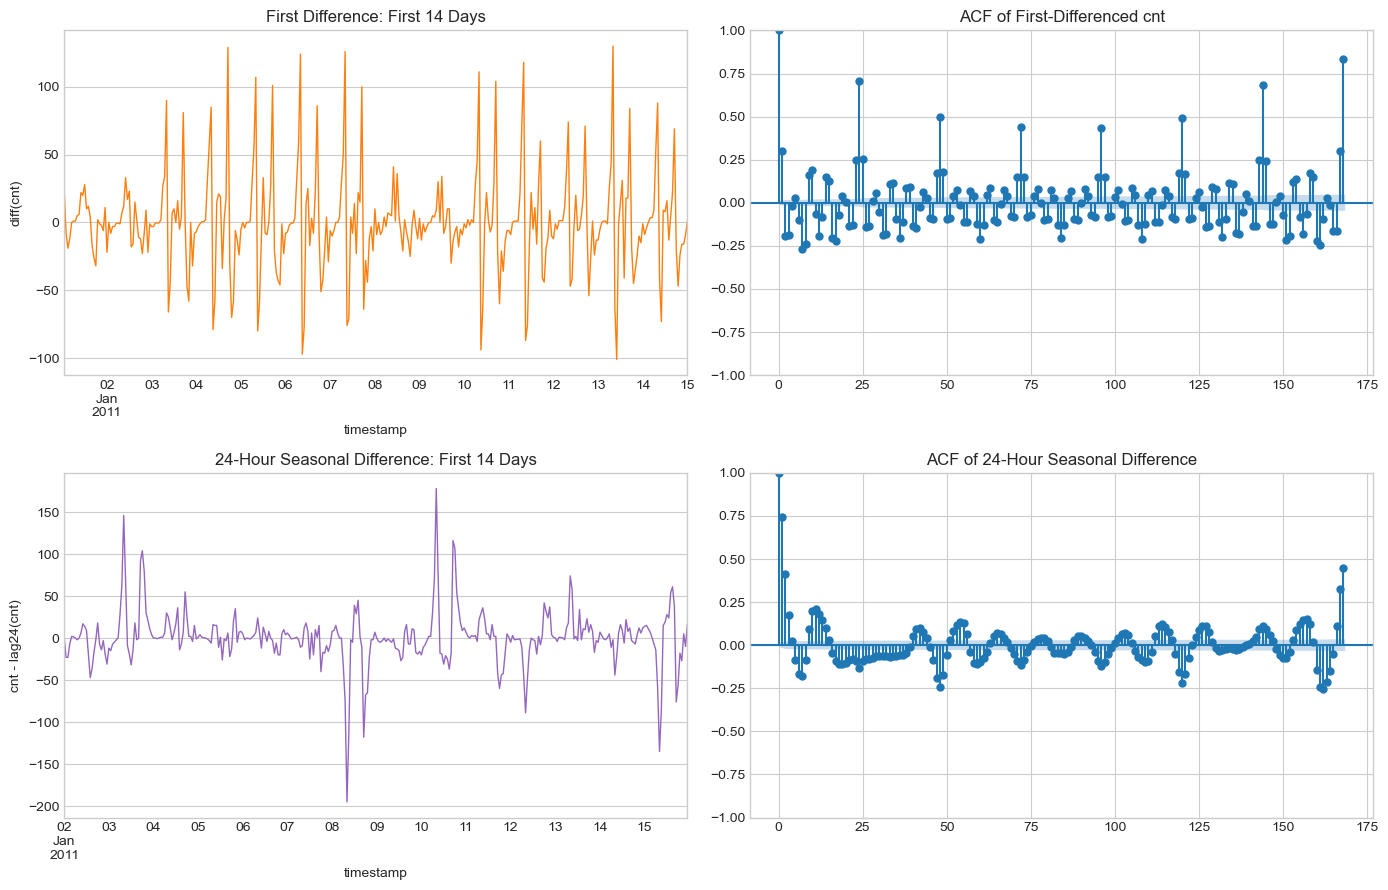

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

diff_1.iloc[:24 * 14].plot(ax=axes[0, 0], color='tab:orange', lw=1)
axes[0, 0].set_title('First Difference: First 14 Days')
axes[0, 0].set_ylabel('diff(cnt)')

plot_acf(diff_1, lags=168, ax=axes[0, 1])
axes[0, 1].set_title('ACF of First-Differenced cnt')

diff_24.iloc[:24 * 14].plot(ax=axes[1, 0], color='tab:purple', lw=1)
axes[1, 0].set_title('24-Hour Seasonal Difference: First 14 Days')
axes[1, 0].set_ylabel('cnt - lag24(cnt)')

plot_acf(diff_24, lags=168, ax=axes[1, 1])
axes[1, 1].set_title('ACF of 24-Hour Seasonal Difference')

plt.tight_layout()
plt.show()

A quick reading of the dependence results suggests:
- the raw series has very strong persistence and daily structure
- first differencing is not enough to remove the main seasonal pattern
- differencing at lag 24 makes the series much simpler

That is why the `ARIMA` benchmark below is applied to the 24-hour differenced series rather than to the raw hourly counts.

## 4. Train / validation / test split and lag features

All methods are compared on the same chronological split:
- 60% train
- 20% validation
- 20% test

We also create lag features for the regression model.

In [9]:
n = len(model_df)
train_end = int(n * 0.6)
valid_end = int(n * 0.8)

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

split_summary = pd.DataFrame({
    'rows': [len(train_df), len(valid_df), len(test_df)],
    'start': [train_df.index.min(), valid_df.index.min(), test_df.index.min()],
    'end': [train_df.index.max(), valid_df.index.max(), test_df.index.max()],
}, index=['train', 'validation', 'test'])

prepared_df = model_df.copy()
for lag in [1, 2, 3, 24, 168]:
    prepared_df[f'lag_{lag}'] = prepared_df['cnt'].shift(lag)
prepared_df = prepared_df.dropna().copy()

split_summary

,rows,start,end
train,10526,2011-01-01 00:00:00,2012-03-14 13:00:00
validation,3509,2012-03-14 14:00:00,2012-08-07 18:00:00
test,3509,2012-08-07 19:00:00,2012-12-31 23:00:00


In [10]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metric_dict(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': rmse(y_true, y_pred),
    }

## 5. Model 1: ARIMA benchmark on the 24-hour differenced series

To keep the classical benchmark close to the course material while still respecting the hourly seasonality, we define:

`z_t = y_t - y_{t-24}`

Then we fit ordinary non-seasonal ARIMA models to `z_t`. We compare a small number of candidate orders on the validation split and keep the best one.

In [11]:
seasonal_lag = 24
candidate_orders = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]

z_train = train_df['cnt'].diff(seasonal_lag).dropna()
combined_train_valid = pd.concat([train_df['cnt'], valid_df['cnt']])
z_valid = combined_train_valid.diff(seasonal_lag).loc[valid_df.index]

arima_rows = []
for order in candidate_orders:
    fitted = ARIMA(z_train, order=order).fit()
    valid_state = fitted.extend(z_valid)
    valid_pred = valid_state.fittedvalues + combined_train_valid.shift(seasonal_lag).loc[valid_df.index]
    arima_rows.append({
        'order': order,
        'AIC': fitted.aic,
        'BIC': fitted.bic,
        **metric_dict(valid_df['cnt'], valid_pred),
    })

arima_order_df = pd.DataFrame(arima_rows).sort_values(['RMSE', 'AIC']).reset_index(drop=True)
best_order = tuple(arima_order_df.loc[0, 'order'])

arima_order_df

,order,AIC,BIC,MAE,RMSE
0,"(2, 0, 1)",114028.139060,114064.435665,53.437339,84.214021
1,"(2, 0, 0)",114040.104233,114069.141517,53.313483,84.252065
2,"(1, 0, 1)",114073.933353,114102.970637,53.749510,84.725176
3,"(1, 0, 0)",114985.676884,115007.454847,54.894720,90.149606


In [12]:
best_arima_train = ARIMA(z_train, order=best_order).fit()
arima_valid_state = best_arima_train.extend(z_valid)
arima_valid_pred = arima_valid_state.fittedvalues + combined_train_valid.shift(seasonal_lag).loc[valid_df.index]

combined_all = pd.concat([train_df['cnt'], valid_df['cnt'], test_df['cnt']])
z_train_valid = combined_train_valid.diff(seasonal_lag).dropna()
z_test = combined_all.diff(seasonal_lag).loc[test_df.index]
best_arima_train_valid = ARIMA(z_train_valid, order=best_order).fit()
arima_test_state = best_arima_train_valid.extend(z_test)
arima_test_pred = arima_test_state.fittedvalues + combined_all.shift(seasonal_lag).loc[test_df.index]

print('Best ARIMA order:', best_order)
pd.DataFrame([
    {'split': 'validation', **metric_dict(valid_df['cnt'], arima_valid_pred)},
    {'split': 'test', **metric_dict(test_df['cnt'], arima_test_pred)},
])

Best ARIMA order: (2, 0, 1)


,split,MAE,RMSE
0,validation,53.437339,84.214021
1,test,51.631000,84.918738


## 6. Model 2: Lagged Regression

This model combines explicit lag features with external weather and calendar information.

The lag choices are intentionally simple and interpretable:
- `lag_1`, `lag_2`, `lag_3` for short-run persistence
- `lag_24` for the daily cycle
- `lag_168` for the weekly cycle

In [13]:
reg_df = pd.get_dummies(
    prepared_df,
    columns=['season', 'mnth', 'hr', 'weekday', 'weathersit'],
    drop_first=True,
)

reg_train = reg_df.loc[reg_df.index < valid_df.index.min()].copy()
reg_valid = reg_df.loc[(reg_df.index >= valid_df.index.min()) & (reg_df.index < test_df.index.min())].copy()
reg_test = reg_df.loc[reg_df.index >= test_df.index.min()].copy()

reg_features = [col for col in reg_df.columns if col != 'cnt']

lag_model = LinearRegression()
lag_model.fit(reg_train[reg_features], reg_train['cnt'])

lag_valid_pred = pd.Series(lag_model.predict(reg_valid[reg_features]), index=reg_valid.index)
lag_test_pred = pd.Series(lag_model.predict(reg_test[reg_features]), index=reg_test.index)

pd.DataFrame([
    {'split': 'validation', **metric_dict(reg_valid['cnt'], lag_valid_pred)},
    {'split': 'test', **metric_dict(reg_test['cnt'], lag_test_pred)},
])

,split,MAE,RMSE
0,validation,45.980923,65.780810
1,test,46.221914,68.315289


## 7. Sequence-model helper setup

For the neural models, we use the same multivariate feature set and compare different window lengths.

The idea is simple:
- `window = 24` lets the model see the previous day
- `window = 72` lets it see the previous three days
- `window = 168` lets it see the previous week

This is especially useful because the earlier lag analysis suggested that weekly information may still matter.

In [14]:
seq_features = ['cnt', 'temp', 'hum', 'windspeed', 'hr', 'weekday', 'workingday', 'holiday', 'weathersit', 'is_imputed']

train_stats = train_df[seq_features]
feature_means = train_stats.mean()
feature_stds = train_stats.std().replace(0, 1)

scaled_features = (model_df[seq_features] - feature_means) / feature_stds
scaled_target = (model_df['cnt'] - feature_means['cnt']) / feature_stds['cnt']

feature_values = scaled_features.values.astype('float32')
target_values = scaled_target.values.astype('float32')

class SeqNet(nn.Module):
    def __init__(self, n_features, model_type='lstm', hidden_size=32):
        super().__init__()
        if model_type == 'lstm':
            self.rnn = nn.LSTM(n_features, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(n_features, hidden_size, nonlinearity='tanh', batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def run_sequence_model(model_type, window, epochs=SEQ_EPOCHS, hidden_size=SEQ_HIDDEN_SIZE):
    X_list, y_list, index_list = [], [], []
    for i in range(window, len(model_df)):
        X_list.append(feature_values[i - window:i])
        y_list.append(target_values[i])
        index_list.append(model_df.index[i])

    X_all = np.stack(X_list)
    y_all = np.array(y_list, dtype='float32')
    index_array = np.array(index_list)

    train_mask = index_array < valid_df.index.min()
    valid_mask = (index_array >= valid_df.index.min()) & (index_array < test_df.index.min())
    test_mask = index_array >= test_df.index.min()

    X_train = torch.tensor(X_all[train_mask])
    y_train = torch.tensor(y_all[train_mask]).unsqueeze(-1)
    X_valid = torch.tensor(X_all[valid_mask])
    y_valid = torch.tensor(y_all[valid_mask]).unsqueeze(-1)
    X_test = torch.tensor(X_all[test_mask])

    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)

    model = SeqNet(n_features=X_train.shape[-1], model_type=model_type, hidden_size=hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    best_state = None
    best_val_loss = float('inf')
    history_rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_valid), torch.tensor(y_all[valid_mask]).unsqueeze(-1)).item()

        history_rows.append({'epoch': epoch, 'train_loss': float(np.mean(batch_losses)), 'val_loss': float(val_loss)})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        valid_scaled = model(X_valid).squeeze(-1).numpy()
        test_scaled = model(X_test).squeeze(-1).numpy()

    target_scale = float(feature_stds['cnt'])
    target_mean = float(feature_means['cnt'])
    valid_pred = pd.Series(valid_scaled * target_scale + target_mean, index=index_array[valid_mask])
    test_pred = pd.Series(test_scaled * target_scale + target_mean, index=index_array[test_mask])

    result = {
        'model': model_type.upper(),
        'window': window,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'history': pd.DataFrame(history_rows),
        'val_MAE': metric_dict(model_df.loc[valid_pred.index, 'cnt'], valid_pred)['MAE'],
        'val_RMSE': metric_dict(model_df.loc[valid_pred.index, 'cnt'], valid_pred)['RMSE'],
        'test_MAE': metric_dict(model_df.loc[test_pred.index, 'cnt'], test_pred)['MAE'],
        'test_RMSE': metric_dict(model_df.loc[test_pred.index, 'cnt'], test_pred)['RMSE'],
    }
    return result

## 8. LSTM window comparison

Instead of fixing the LSTM window at 24 hours, we now compare three windows: `24`, `72`, and `168`.

This lets us directly check whether giving the model access to a longer history improves performance.

In [15]:
lstm_windows = LSTM_WINDOWS
lstm_runs = [run_sequence_model('lstm', window=w) for w in lstm_windows]

lstm_window_df = pd.DataFrame([
    {
        'window': run['window'],
        'val_MAE': run['val_MAE'],
        'val_RMSE': run['val_RMSE'],
        'test_MAE': run['test_MAE'],
        'test_RMSE': run['test_RMSE'],
    }
    for run in lstm_runs
]).sort_values('val_RMSE').reset_index(drop=True)

best_lstm_run = min(lstm_runs, key=lambda run: run['val_RMSE'])
best_lstm_window = best_lstm_run['window']

lstm_window_df

,window,val_MAE,val_RMSE,test_MAE,test_RMSE
0,72,41.852948,63.257258,44.582399,70.855408
1,168,42.136024,64.887846,44.294313,72.300794
2,24,44.233877,67.337277,45.901442,74.673794


## 9. RNN benchmark

To compare the two sequence-model families more fairly, we fit a simple vanilla `RNN` using the same window length selected for the best LSTM run.

This is a useful benchmark because it shows whether the gated LSTM architecture is actually helping on this dataset.

In [16]:
rnn_run = run_sequence_model('rnn', window=best_lstm_window)

pd.DataFrame([
    {
        'model': 'LSTM',
        'window': best_lstm_run['window'],
        'val_MAE': best_lstm_run['val_MAE'],
        'val_RMSE': best_lstm_run['val_RMSE'],
        'test_MAE': best_lstm_run['test_MAE'],
        'test_RMSE': best_lstm_run['test_RMSE'],
    },
    {
        'model': 'RNN',
        'window': rnn_run['window'],
        'val_MAE': rnn_run['val_MAE'],
        'val_RMSE': rnn_run['val_RMSE'],
        'test_MAE': rnn_run['test_MAE'],
        'test_RMSE': rnn_run['test_RMSE'],
    },
])

,model,window,val_MAE,val_RMSE,test_MAE,test_RMSE
0,LSTM,72,41.852948,63.257258,44.582399,70.855408
1,RNN,72,44.647041,66.987347,46.920470,73.386911


## 10. ARIMAX extension

You asked whether it would be possible to add a `SARIMAX` or `ARIMAX` style extension. It is possible, and the first lightweight version ran quickly, but it underperformed because it did not use the strongest signal in the data: recent demand itself.

So in this revised version, the ARIMAX block behaves more like a dynamic regression with ARMA-style errors. It uses:
- weather variables
- working-day indicators
- cyclic hour and weekday features
- explicit lagged demand terms: `lag_1`, `lag_2`, `lag_3`, `lag_24`, `lag_168`

This makes the ARIMAX comparison much fairer, because it now has access to the same core persistence structure that strongly helps the lagged regression model.

In [17]:
RUN_ARIMAX = RUN_ARIMAX
arimax_metrics = None
arimax_valid_pred = None
arimax_test_pred = None

if RUN_ARIMAX:
    arimax_df = prepared_df[['cnt', 'workingday', 'holiday', 'temp', 'hum', 'windspeed', 'is_imputed', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168']].copy()
    arimax_df['hr_sin'] = np.sin(2 * np.pi * prepared_df['hr'] / 24)
    arimax_df['hr_cos'] = np.cos(2 * np.pi * prepared_df['hr'] / 24)
    arimax_df['week_sin'] = np.sin(2 * np.pi * prepared_df['weekday'] / 7)
    arimax_df['week_cos'] = np.cos(2 * np.pi * prepared_df['weekday'] / 7)
    arimax_df = arimax_df.astype(float)

    arimax_train = arimax_df.loc[arimax_df.index < valid_df.index.min()].copy()
    arimax_valid = arimax_df.loc[(arimax_df.index >= valid_df.index.min()) & (arimax_df.index < test_df.index.min())].copy()
    arimax_test = arimax_df.loc[arimax_df.index >= test_df.index.min()].copy()

    arimax_exog = [c for c in arimax_df.columns if c != 'cnt']

    arimax_fit = SARIMAX(
        arimax_train['cnt'],
        exog=arimax_train[arimax_exog],
        order=ARIMAX_ORDER,
        seasonal_order=(0, 0, 0, 0),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=ARIMAX_MAXITER)
    arimax_valid_pred = pd.Series(
        arimax_fit.forecast(steps=len(arimax_valid), exog=arimax_valid[arimax_exog]),
        index=arimax_valid.index,
    )

    arimax_fit_full = SARIMAX(
        pd.concat([arimax_train['cnt'], arimax_valid['cnt']]),
        exog=pd.concat([arimax_train[arimax_exog], arimax_valid[arimax_exog]]),
        order=ARIMAX_ORDER,
        seasonal_order=(0, 0, 0, 0),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=ARIMAX_MAXITER)
    arimax_test_pred = pd.Series(
        arimax_fit_full.forecast(steps=len(arimax_test), exog=arimax_test[arimax_exog]),
        index=arimax_test.index,
    )

    arimax_metrics = pd.DataFrame([
        {'split': 'validation', **metric_dict(arimax_valid['cnt'], arimax_valid_pred)},
        {'split': 'test', **metric_dict(arimax_test['cnt'], arimax_test_pred)},
    ])
    display(arimax_metrics)
else:
    print('ARIMAX module skipped in this run. Set RUN_ARIMAX = True if you want to include the extra comparison.')

/Users/ren/anaconda3/envs/general/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,split,MAE,RMSE
0,validation,57.608877,91.986782
1,test,58.695551,94.635323


## 11. Compare the fitted models

We now assemble the current results into one table. The `ARIMAX` row is included only if the optional module was actually run.

In [18]:
comparison_rows = [
    {'model': 'ARIMA', 'split': 'validation', **metric_dict(valid_df['cnt'], arima_valid_pred)},
    {'model': 'ARIMA', 'split': 'test', **metric_dict(test_df['cnt'], arima_test_pred)},
    {'model': 'Lagged Regression', 'split': 'validation', **metric_dict(reg_valid['cnt'], lag_valid_pred)},
    {'model': 'Lagged Regression', 'split': 'test', **metric_dict(reg_test['cnt'], lag_test_pred)},
    {'model': f'LSTM (window={best_lstm_window})', 'split': 'validation', **metric_dict(model_df.loc[best_lstm_run['valid_pred'].index, 'cnt'], best_lstm_run['valid_pred'])},
    {'model': f'LSTM (window={best_lstm_window})', 'split': 'test', **metric_dict(model_df.loc[best_lstm_run['test_pred'].index, 'cnt'], best_lstm_run['test_pred'])},
    {'model': f'RNN (window={best_lstm_window})', 'split': 'validation', **metric_dict(model_df.loc[rnn_run['valid_pred'].index, 'cnt'], rnn_run['valid_pred'])},
    {'model': f'RNN (window={best_lstm_window})', 'split': 'test', **metric_dict(model_df.loc[rnn_run['test_pred'].index, 'cnt'], rnn_run['test_pred'])},
]

if arimax_metrics is not None:
    comparison_rows.extend([
        {'model': 'ARIMAX', 'split': 'validation', **metric_dict(valid_df['cnt'], arimax_valid_pred)},
        {'model': 'ARIMAX', 'split': 'test', **metric_dict(test_df['cnt'], arimax_test_pred)},
    ])

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,model,split,MAE,RMSE
0,ARIMA,validation,53.437339,84.214021
1,ARIMA,test,51.631000,84.918738
2,Lagged Regression,validation,45.980923,65.780810
3,Lagged Regression,test,46.221914,68.315289
4,LSTM (window=72),validation,41.852948,63.257258
5,LSTM (window=72),test,44.582399,70.855408
6,RNN (window=72),validation,44.647041,66.987347
7,RNN (window=72),test,46.920470,73.386911
8,ARIMAX,validation,57.608877,91.986782
9,ARIMAX,test,58.695551,94.635323


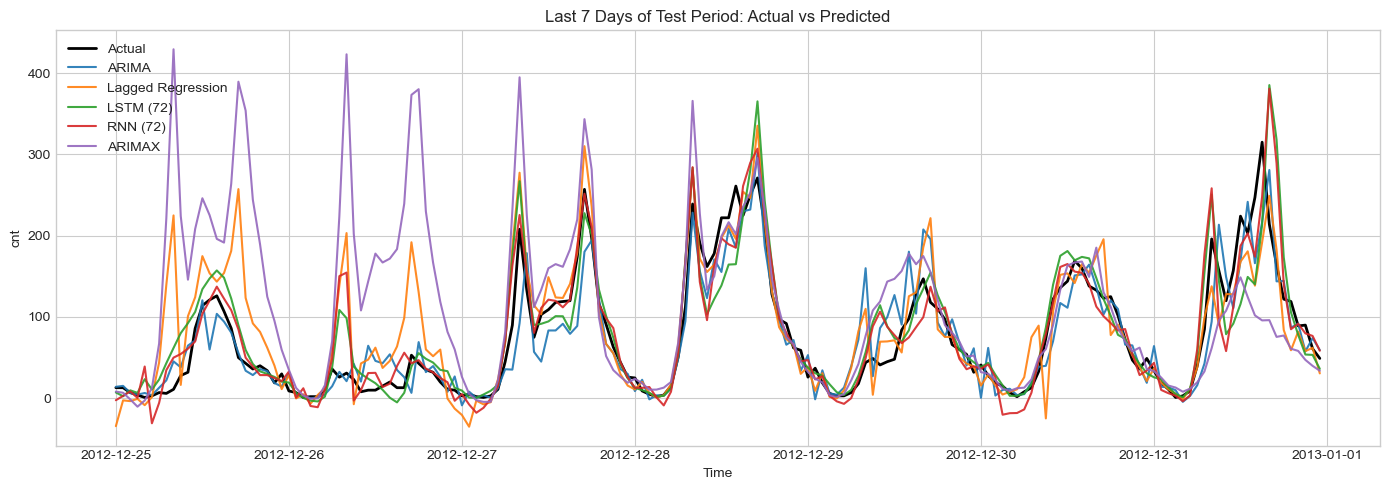

In [19]:
plot_start = test_df.index[-24 * 7]

plt.figure(figsize=(14, 5))
plt.plot(test_df.loc[plot_start:, 'cnt'], label='Actual', color='black', lw=2)
plt.plot(arima_test_pred.loc[plot_start:], label='ARIMA', alpha=0.9)
plt.plot(lag_test_pred.loc[plot_start:], label='Lagged Regression', alpha=0.9)
plt.plot(best_lstm_run['test_pred'].loc[plot_start:], label=f'LSTM ({best_lstm_window})', alpha=0.9)
plt.plot(rnn_run['test_pred'].loc[plot_start:], label=f'RNN ({best_lstm_window})', alpha=0.9)
if arimax_test_pred is not None:
    plt.plot(arimax_test_pred.loc[plot_start:], label='ARIMAX', alpha=0.9)
plt.title('Last 7 Days of Test Period: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('cnt')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Initial interpretation

This first pipeline now answers a few practical questions:
- whether a 24-hour differenced `ARIMA` benchmark is still useful on the hourly data
- whether explicit lag features beat a neural sequence model on this problem
- whether giving the `LSTM` a longer window helps
- whether a simple `RNN` behaves differently from the `LSTM`

From here, the next round of refinement could go in several directions:
- tune the lag feature set for `Lagged Regression`
- adjust the hidden size, epochs, or feature encoding for the neural models
- turn on the optional `ARIMAX` extension and compare it with the current methods
- decide which subset of methods should become the focus of the final report